#Imports

In [ ]:
# Install necessary libraries for MCAP file parsing and ROS bag support
!pip install -q mcap mcap-ros2-support rosbags

# Standard libraries
import os
import numpy as np
import glob
import re
import time
import json
from pathlib import Path

# MCAP and ROS bag related libraries
from mcap.reader import make_reader
from mcap_ros2.decoder import DecoderFactory
from rosbags.rosbag2 import Reader
from rosbags.typesys import Stores, get_typestore

# Image processing and visualization
import cv2
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

#Process Rosbags

In [ ]:
# Define paths for input bag file and output directory
BAG_PATH = "/content/drive/MyDrive/EE243 Project/data/test_bag_0.mcap"
OUT_PATH = "/content/drive/MyDrive/EE243 Project/data/turtlebot_sequence"

# Create output directories if they don't exist
os.makedirs(f"{OUT_PATH}/rgb", exist_ok=True)
os.makedirs(f"{OUT_PATH}/depth", exist_ok=True)

K = None # Initialize camera intrinsics matrix
rgb_idx = 0 # Counter for RGB frames
depth_idx = 0 # Counter for depth frames

# Open the MCAP bag file and iterate through messages
# Note: Ensure the BAG_PATH exists and is accessible in your Google Drive.
with open(BAG_PATH, "rb") as f:
    # Create a reader for the MCAP file, using a DecoderFactory for ROS2 messages
    reader = make_reader(f, decoder_factories=[DecoderFactory()])
    for schema, channel, message, decoded in reader.iter_decoded_messages():
        topic = channel.topic

        # Extract camera intrinsics from the camera_info topic
        if topic == '/camera/camera/color/camera_info' and K is None:
            K = np.array(decoded.k).reshape(3, 3)
            print(f"Got intrinsics:\n{K}")

        # Process RGB image messages
        elif topic == '/camera/camera/color/image_raw':
            # Convert image data from buffer to numpy array and reshape
            img = np.frombuffer(decoded.data, dtype=np.uint8).reshape(decoded.height, decoded.width, 3)
            # Convert RGB to BGR for OpenCV compatibility and save
            img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(f"{OUT_PATH}/rgb/{rgb_idx:06d}.png", img_bgr)
            rgb_idx += 1
            if rgb_idx % 50 == 0:
                print(f"RGB: {rgb_idx} frames")

        # Process depth image messages
        elif topic == '/camera/camera/depth/image_rect_raw':
            # Convert depth data from buffer to numpy array and reshape
            depth = np.frombuffer(decoded.data, dtype=np.uint16).reshape(decoded.height, decoded.width)
            # Save the depth image
            cv2.imwrite(f"{OUT_PATH}/depth/{depth_idx:06d}.png", depth)
            depth_idx += 1
            if depth_idx % 50 == 0:
                print(f"Depth: {depth_idx} frames")

# Save the camera intrinsics to a numpy file
np.save(f"{OUT_PATH}/intrinsics.npy", K)
print(f"\nDone! RGB: {rgb_idx} frames, Depth: {depth_idx} frames")

# Gaussian Growth Tracking

In [ ]:
# 1. Analyze Gaussian count growth over frames
print("=== Gaussian Count Growth ===")
# Find and sort parameter files based on frame number
files = sorted(glob.glob("/content/drive/MyDrive/EE243 Project/outputs/office0_0/params*.npz"),
               key=lambda f: int(re.search(r'params(\d+)', f).group(1)))
for f in files:
    # Load parameters from each file
    p = np.load(f, allow_pickle=True)
    # Extract frame number from filename
    frame = int(re.search(r'params(\d+)', f).group(1))
    # Print the number of Gaussians (means3D) and file size
    print(f"Frame {frame:4d}: {p['means3D'].shape[0]:,} Gaussians  |  file size: {os.path.getsize(f)/1e6:.1f} MB")

# 2. Test Drive I/O speed by writing and reading a dummy file
print("\n=== Drive I/O Speed ===")
t = time.time()
# Write a dummy numpy array to Drive
np.save("/content/drive/MyDrive/EE243 Project/test_write.npy", np.zeros((1000,1000)))
print(f"Drive write 8MB: {time.time()-t:.2f}s")

t = time.time()
# Read the dummy numpy array from Drive
_ = np.load("/content/drive/MyDrive/EE243 Project/test_write.npy")
print(f"Drive read  8MB: {time.time()-t:.2f}s")
# Remove the dummy file
os.remove("/content/drive/MyDrive/EE243 Project/test_write.npy")

=== Gaussian Count Growth ===
Frame  800: 4,960,464 Gaussians  |  file size: 238.2 MB
Frame  900: 5,085,207 Gaussians  |  file size: 244.1 MB
Frame 1000: 5,177,611 Gaussians  |  file size: 248.6 MB
Frame 1100: 5,299,853 Gaussians  |  file size: 254.5 MB
Frame 1200: 5,397,735 Gaussians  |  file size: 259.1 MB

=== Drive I/O Speed ===
Drive write 8MB: 0.02s
Drive read  8MB: 0.01s


In [ ]:
# Check if Gaussian count is still growing or plateauing by calculating growth rate
print("=== Growth Rate ===")
# Find and sort parameter files based on frame number
files = sorted(glob.glob("/content/drive/MyDrive/EE243 Project/outputs/office0_0/params*.npz"),
               key=lambda f: int(re.search(r'params(\d+)', f).group(1)))

counts = []
for f in files:
    # Load parameters from each file
    p = np.load(f, allow_pickle=True)
    # Extract frame number and number of Gaussians
    frame = int(re.search(r'params(\d+)', f).group(1))
    n = p['means3D'].shape[0]
    counts.append((frame, n))

# Calculate and print the growth rate between consecutive frames
for i in range(1, len(counts)):
    f0, n0 = counts[i-1] # Previous frame and Gaussian count
    f1, n1 = counts[i] # Current frame and Gaussian count
    rate = (n1 - n0) / (f1 - f0) # Growth rate per frame
    print(f"Frames {f0}→{f1}: +{n1-n0:,} Gaussians  ({rate:,.0f}/frame)")

=== Growth Rate ===
Frames 800→900: +124,743 Gaussians  (1,247/frame)
Frames 900→1000: +92,404 Gaussians  (924/frame)
Frames 1000→1100: +122,242 Gaussians  (1,222/frame)
Frames 1100→1200: +97,882 Gaussians  (979/frame)


#Diagnostics

In [ ]:
# Load the transforms.json file which contains camera calibration and pose information
with open("/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/transforms.json") as f:
    t = json.load(f)

print(f"Total frames in transforms.json: {len(t['frames'])}")

# Check if all transformation matrices are identity matrices
non_identity = 0
for frame in t['frames']:
    mat = np.array(frame['transform_matrix'])
    # Use np.allclose to compare floating-point arrays for approximate equality
    if not np.allclose(mat, np.eye(4), atol=1e-3):
        non_identity += 1

print(f"Frames with non-identity pose: {non_identity}")
print(f"Frames with identity pose: {len(t['frames']) - non_identity}")

# Check depth coverage by comparing metadata with actual files on disk
print(f"\nRGB frames: {len(t['frames'])}")
depth_frames = [f for f in t['frames'] if 'depth_path' in f]
print(f"Frames with depth_path field: {len(depth_frames)}")

depth_files = os.listdir("/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/depth/")
print(f"Actual depth files on disk: {len(depth_files)}")

Total frames in transforms.json: 733
Frames with non-identity pose: 0
Frames with identity pose: 733

RGB frames: 733
Frames with depth_path field: 733
Actual depth files on disk: 733


In [ ]:
# Load the depth image from the specified path
depth = np.array(Image.open(
    "/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/depth/0.png"
))

# Print information about the depth image
print(f"Depth dtype: {depth.dtype}")
print(f"Depth shape: {depth.shape}")
print(f"Min: {depth.min()}, Max: {depth.max()}, Mean: {depth.mean():.1f}")
# Calculate and print the percentage of non-zero (valid) pixels
print(f"Non-zero pixels: {np.count_nonzero(depth)} / {depth.size}")

# Discuss depth scaling based on common factors
# At scale 6553.5, what does max depth correspond to?
print(f"\nWith scale 6553.5: max depth = {depth.max()/6553.5:.2f}m")
print(f"With scale 1000.0: max depth = {depth.max()/1000.0:.2f}m")

Depth dtype: uint16
Depth shape: (480, 640)
Min: 0, Max: 52388, Mean: 1289.8
Non-zero pixels: 68155 / 307200

With scale 6553.5: max depth = 7.99m
With scale 1000.0: max depth = 52.39m


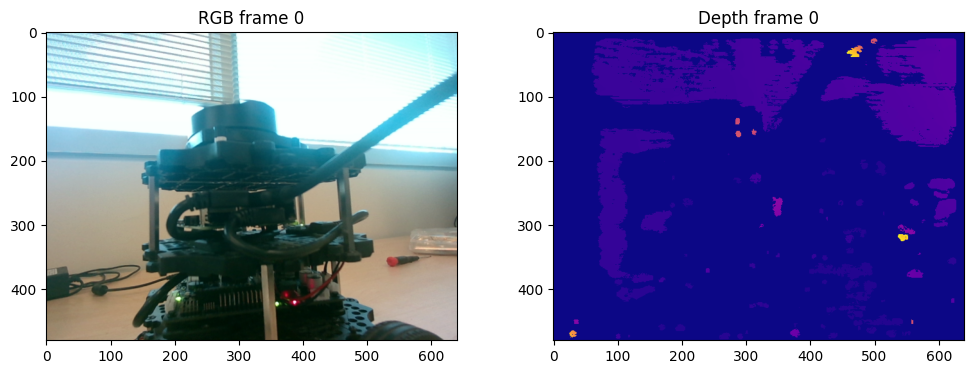

Saved to Drive


In [ ]:
# Load RGB and Depth images for visualization
rgb = Image.open("/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/rgb/0.png")
depth = Image.open("/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/depth/0.png")

# Create a figure with two subplots to display RGB and Depth images side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rgb); axes[0].set_title("RGB frame 0")
# Use 'plasma' colormap for better visualization of depth values
axes[1].imshow(np.array(depth), cmap='plasma'); axes[1].set_title("Depth frame 0")
plt.savefig("/content/drive/MyDrive/EE243 Project/frame0_check.png")
plt.show()
print("Saved to Drive")

#Check sparsity

In [ ]:
depth_dir = "/content/drive/MyDrive/EE243 Project/mcap2nerfcapturedataset_results/seq0/depth/"
# Get all depth files and sort them numerically
files = sorted(os.listdir(depth_dir), key=lambda x: int(x.split('.')[0]))

sparsities = []
# Sample every 50th depth frame to calculate its valid depth percentage
for fname in files[::50]:  # sample every 50th frame
    d = np.array(Image.open(os.path.join(depth_dir, fname)))
    # Calculate the percentage of non-zero pixels (valid depth readings)
    nonzero_pct = np.count_nonzero(d) / d.size * 100
    sparsities.append((int(fname.split('.')[0]), nonzero_pct))
    print(f"Frame {int(fname.split('.')[0]):4d}: {nonzero_pct:.1f}% valid depth")

# Calculate and print the average valid depth percentage across the sampled frames
print(f"\nAverage valid depth: {np.mean([s[1] for s in sparsities]):.1f}%")

Frame    0: 22.2% valid depth
Frame   50: 65.5% valid depth
Frame  100: 70.0% valid depth
Frame  150: 55.9% valid depth
Frame  200: 63.3% valid depth
Frame  250: 59.7% valid depth
Frame  300: 81.6% valid depth
Frame  350: 61.1% valid depth
Frame  400: 57.3% valid depth
Frame  450: 72.8% valid depth
Frame  500: 73.9% valid depth
Frame  550: 72.7% valid depth
Frame  600: 47.1% valid depth
Frame  650: 38.4% valid depth
Frame  700: 39.6% valid depth

Average valid depth: 58.7%
